In [1]:
# Data Loading And Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


In [3]:
df = pd.read_csv(r"C:\Users\stran\Desktop\DS\Student Performance analyzer\student_performance_dataset.csv")

print("=== Dataset Overview ===")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()


=== Dataset Overview ===
Shape: (120, 10)

Columns: ['Student_ID', 'Math', 'Physics', 'Chemistry', 'English', 'Computer_Science', 'Attendance_Percent', 'Study_Hours_Per_Day', 'Average_Marks', 'Final_Grade']


,Student_ID,Math,Physics,Chemistry,English,Computer_Science,Attendance_Percent,Study_Hours_Per_Day,Average_Marks,Final_Grade
0,S001,82.00,70.00,42,52,81,69.00,4.50,65.40,C
1,S002,60.00,67.00,56,37,75,82.00,1.70,59.00,C
2,S003,58.00,68.00,54,49,72,57.00,-1.00,60.20,C
3,S004,92.00,80.00,80,81,90,72.00,1.70,84.60,B
4,S005,NaN,NaN,85,66,65,NaN,NaN,72.00,B


In [4]:
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\n=== Basic Stats ===")
df.describe()


=== Missing Values ===
Student_ID              0
Math                   10
Physics                10
Chemistry               0
English                 0
Computer_Science        0
Attendance_Percent     10
Study_Hours_Per_Day     9
Average_Marks           0
Final_Grade             0
dtype: int64

=== Basic Stats ===


,Math,Physics,Chemistry,English,Computer_Science,Attendance_Percent,Study_Hours_Per_Day,Average_Marks
count,110.00,110.00,120.00,120.00,120.00,110.00,111.00,120.00
mean,68.04,67.78,66.25,67.99,70.53,77.24,2.52,68.34
std,19.37,18.19,18.12,19.65,17.77,16.34,1.54,9.67
min,35.00,35.00,35.00,35.00,40.00,55.00,-1.00,38.60
25%,51.00,51.00,52.00,52.00,55.75,64.00,1.20,60.75
50%,68.50,68.50,68.50,68.50,72.00,75.00,2.70,67.40
75%,84.75,83.00,80.00,85.25,86.00,87.00,3.80,75.75
max,99.00,99.00,99.00,99.00,99.00,120.00,4.90,95.33


In [5]:
print("=== Before Cleaning ===")
print("Negative Study_Hours:", (df["Study_Hours_Per_Day"] < 0).sum())
print("Attendance > 100:", (df["Attendance_Percent"] > 100).sum())

# Fill NaN with column means
for col in ["Math", "Physics", "Attendance_Percent", "Study_Hours_Per_Day"]:
    df[col].fillna(df[col].mean(), inplace=True)
    print(f"Filled NaN in '{col}' with mean = {df[col].mean():.2f}")

# Fix negative study hours → median
median_study = df.loc[df["Study_Hours_Per_Day"] >= 0, "Study_Hours_Per_Day"].median()
df.loc[df["Study_Hours_Per_Day"] < 0, "Study_Hours_Per_Day"] = median_study
print(f"\nFixed negative Study_Hours → median ({median_study:.2f})")

# Cap attendance at 100
df["Attendance_Percent"] = df["Attendance_Percent"].clip(upper=100)
print("Capped Attendance_Percent at 100")

print("\n=== After Cleaning ===")
print("Missing values:", df.isnull().sum().sum())
print("Study_Hours range:", df["Study_Hours_Per_Day"].min(), "–", df["Study_Hours_Per_Day"].max())
print("Attendance range:", df["Attendance_Percent"].min(), "–", df["Attendance_Percent"].max())

df.to_csv("student_performance_cleaned.csv", index=False)
print("\n✅ Saved: student_performance_cleaned.csv")


=== Before Cleaning ===
Negative Study_Hours: 6
Attendance > 100: 6
Filled NaN in 'Math' with mean = 68.04
Filled NaN in 'Physics' with mean = 67.78
Filled NaN in 'Attendance_Percent' with mean = 77.24
Filled NaN in 'Study_Hours_Per_Day' with mean = 2.52

Fixed negative Study_Hours → median (2.65)
Capped Attendance_Percent at 100

=== After Cleaning ===
Missing values: 0
Study_Hours range: 0.5 – 4.9
Attendance range: 55.0 – 100.0

✅ Saved: student_performance_cleaned.csv


In [6]:
# Subject Wise Score Visualization

In [7]:
subjects = ["Math", "Physics", "Chemistry", "English", "Computer_Science"]
grade_colors = {"A": "#2ecc71", "B": "#f39c12", "C": "#e74c3c"}



Text(0.5, 0.98, 'Subject-wise Score Analysis')

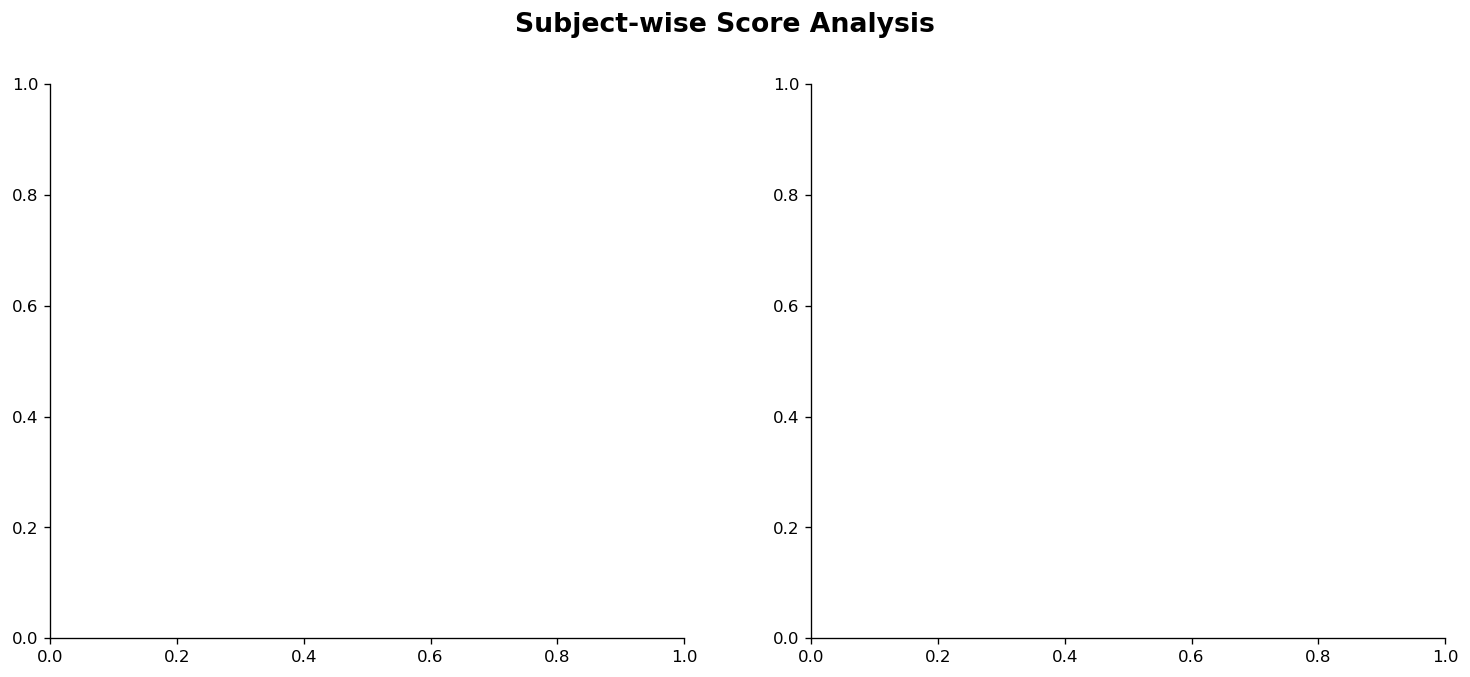

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Subject-wise Score Analysis", fontsize=16, fontweight="bold")



In [9]:
# Average scores bar chart
avg = df[subjects].mean().sort_values()
colors = sns.color_palette("Blues_d", len(subjects))
bars = axes[0].barh(avg.index, avg.values, color=colors, edgecolor="white")
for bar, val in zip(bars, avg.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}", va="center", fontsize=10)
axes[0].set_xlim(0, 110)
axes[0].set_title("Average Marks per Subject")
axes[0].set_xlabel("Average Marks")




Text(0.5, 5.33333333333334, 'Average Marks')

In [10]:
# Box plot — spread per subject
df[subjects].plot(kind="box", ax=axes[1], patch_artist=True,
                  boxprops=dict(facecolor="#4C72B0", alpha=0.6),
                  medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Score Distribution per Subject")
axes[1].set_ylabel("Marks")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
# plt.savefig("plots/01_subject_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: plots/01_subject_scores.png")

<Figure size 768x576 with 0 Axes>

✅ Saved: plots/01_subject_scores.png


In [11]:
# Grade Distribution Analysis

In [12]:
import os
os.makedirs("plots", exist_ok=True)



Text(0.5, 0.98, 'Grade Distribution Analysis')

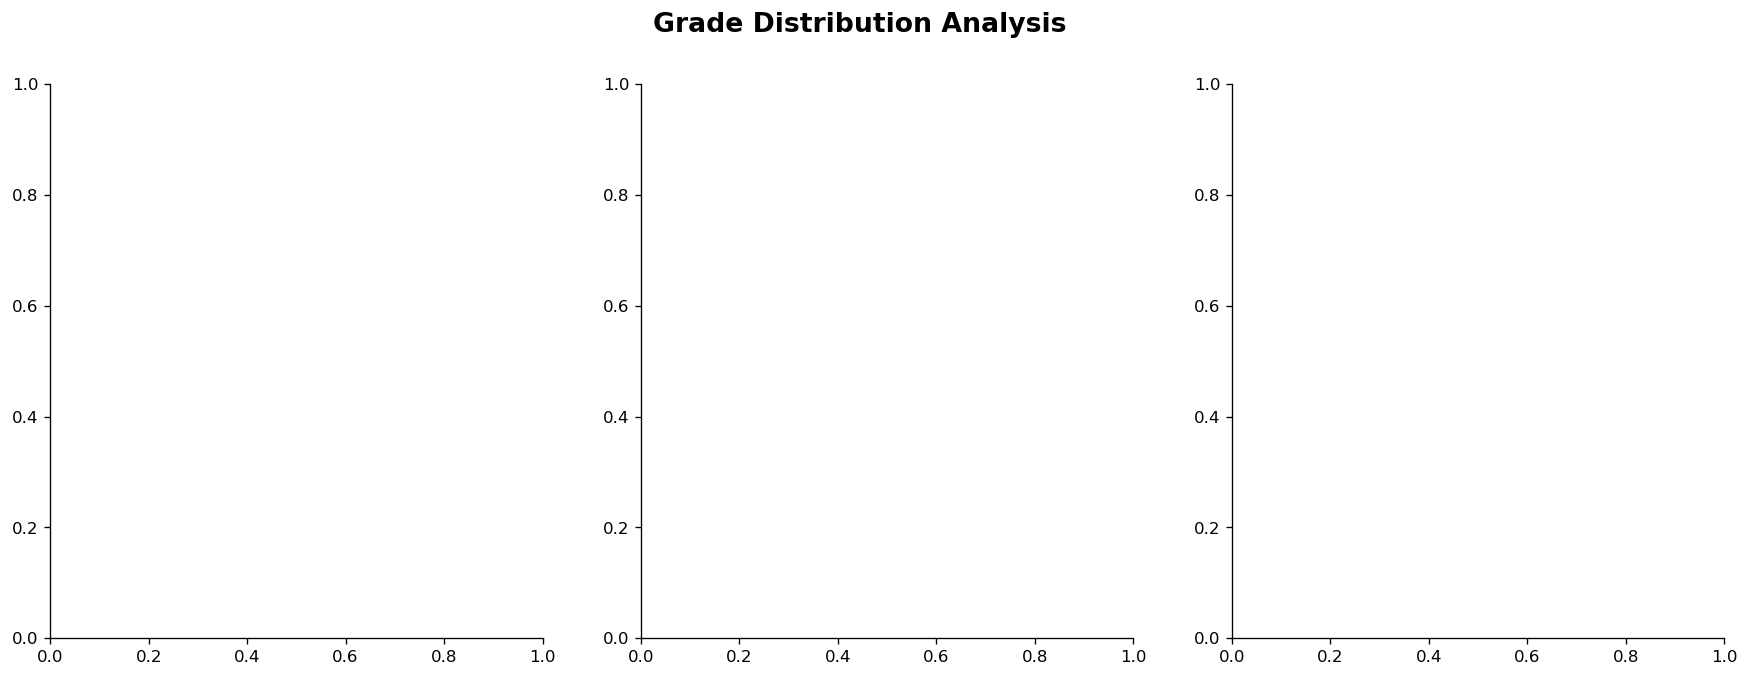

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Grade Distribution Analysis", fontsize=16, fontweight="bold")



In [14]:
# Donut chart
grade_colors = {"A": "#2ecc71", "B": "#f39c12", "C": "#e74c3c", "D": "#9b59b6"}  # ← add D

grade_counts = df["Final_Grade"].value_counts()
axes[0].pie(grade_counts.values, labels=grade_counts.index, autopct="%1.1f%%",
            colors=[grade_colors.get(g, "#95a5a6") for g in grade_counts.index],  # ← .get() as safety net
            startangle=90, wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2))
axes[0].set_title("Grade Split (Donut)")

Text(0.5, 1.0, 'Grade Split (Donut)')

In [15]:
# Count bar
axes[1].bar(grade_counts.index, grade_counts.values,
            color=[grade_colors[g] for g in grade_counts.index],
            edgecolor="white", linewidth=1.2)
for i, (g, v) in enumerate(grade_counts.items()):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontsize=12, fontweight="bold")
axes[1].set_title("Student Count per Grade")
axes[1].set_xlabel("Grade"); axes[1].set_ylabel("Count")



Text(596.1568627450982, 0.5, 'Count')

In [16]:
grade_colors = {"A": "#2ecc71", "B": "#f39c12", "C": "#e74c3c", "D": "#9b59b6"}

In [17]:
# Attendance band vs grade
df["Attendance_Band"] = pd.cut(df["Attendance_Percent"],
    bins=[0, 65, 75, 85, 100], labels=["<65%", "65-75%", "75-85%", "85-100%"])
att_grade = df.groupby(["Attendance_Band", "Final_Grade"]).size().unstack(fill_value=0)
att_grade.plot(kind="bar", ax=axes[2], stacked=True,
               color=[grade_colors[g] for g in att_grade.columns], edgecolor="white")
axes[2].set_title("Attendance Band vs Grade")
axes[2].set_xlabel("Attendance Band"); axes[2].set_ylabel("Student Count")
axes[2].tick_params(axis="x", rotation=15)
axes[2].legend(title="Grade")

plt.tight_layout()
plt.savefig("plots/02_grade_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: plots/02_grade_distribution.png")


<Figure size 768x576 with 0 Axes>

✅ Saved: plots/02_grade_distribution.png


In [18]:
# Correlation Analysis

Text(0.5, 0.98, 'Correlation & Relationship Analysis')

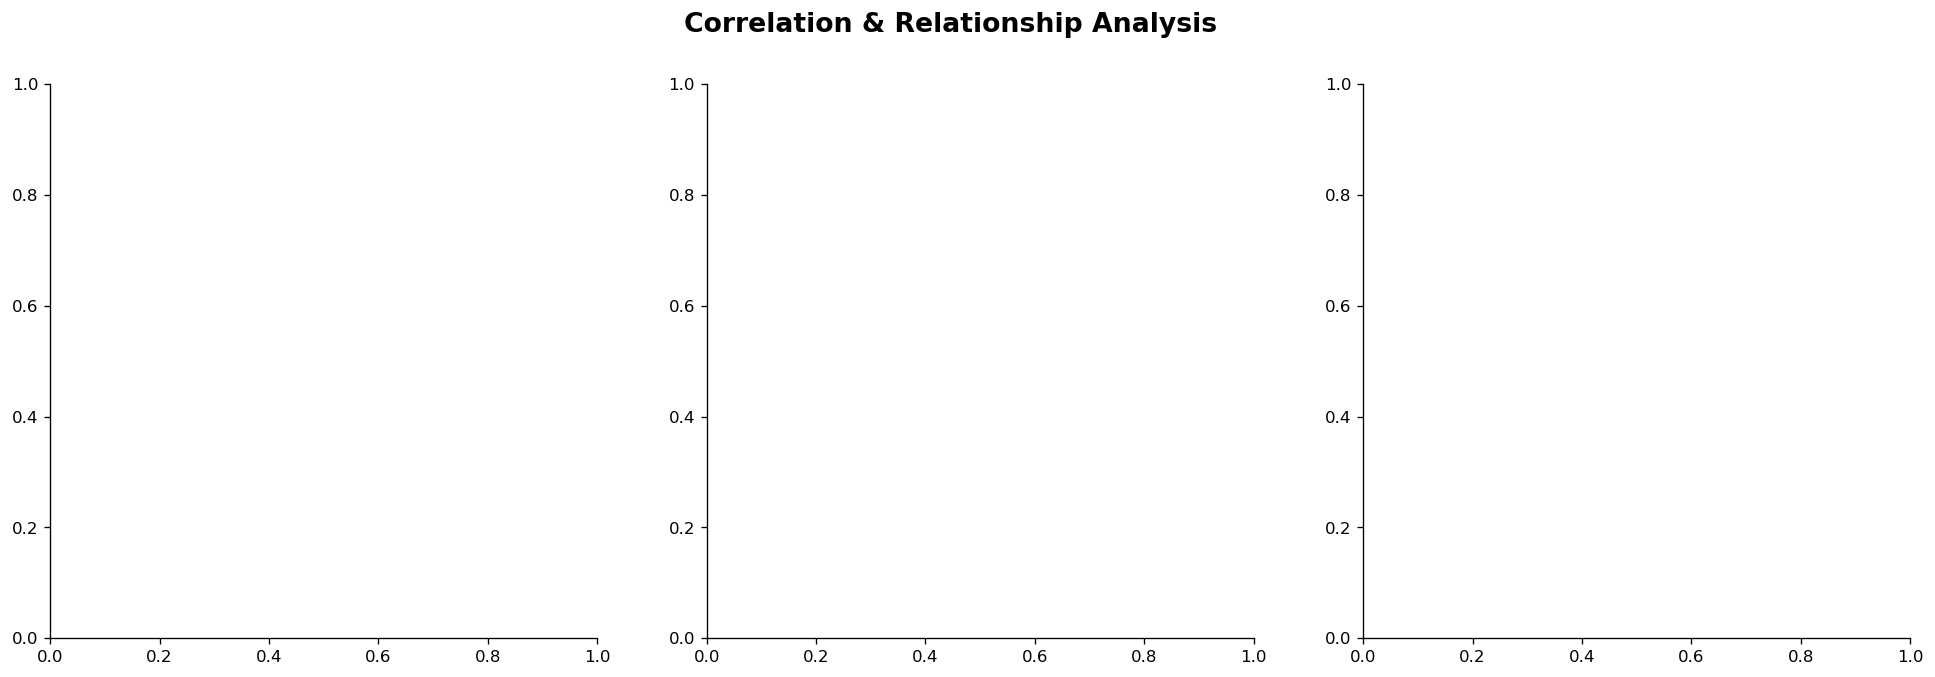

In [19]:
numeric_cols = subjects + ["Attendance_Percent", "Study_Hours_Per_Day", "Average_Marks"]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Correlation & Relationship Analysis", fontsize=16, fontweight="bold")

In [20]:
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[0], linewidths=0.4, annot_kws={"size": 8},
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Correlation Heatmap")
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].tick_params(axis="y", rotation=0, labelsize=8)

In [21]:
# Study Hours vs Avg Marks
for grade, grp in df.groupby("Final_Grade"):
    axes[1].scatter(grp["Study_Hours_Per_Day"], grp["Average_Marks"],
                    label=f"Grade {grade}", color=grade_colors[grade],
                    alpha=0.75, s=55, edgecolors="white", linewidths=0.4)
z = np.polyfit(df["Study_Hours_Per_Day"], df["Average_Marks"], 1)
x_line = np.linspace(df["Study_Hours_Per_Day"].min(), df["Study_Hours_Per_Day"].max(), 100)
axes[1].plot(x_line, np.poly1d(z)(x_line), "k--", alpha=0.4, label="Trend")
axes[1].set_title(f"Study Hours vs Avg Marks\n(r = {df['Study_Hours_Per_Day'].corr(df['Average_Marks']):.2f})")
axes[1].set_xlabel("Study Hours / Day"); axes[1].set_ylabel("Average Marks")
axes[1].legend()

In [22]:
# Attendance vs Avg Marks
for grade, grp in df.groupby("Final_Grade"):
    axes[2].scatter(grp["Attendance_Percent"], grp["Average_Marks"],
                    label=f"Grade {grade}", color=grade_colors[grade],
                    alpha=0.75, s=55, edgecolors="white", linewidths=0.4)
z2 = np.polyfit(df["Attendance_Percent"], df["Average_Marks"], 1)
x2 = np.linspace(df["Attendance_Percent"].min(), df["Attendance_Percent"].max(), 100)
axes[2].plot(x2, np.poly1d(z2)(x2), "k--", alpha=0.4, label="Trend")
axes[2].set_title(f"Attendance vs Avg Marks\n(r = {df['Attendance_Percent'].corr(df['Average_Marks']):.2f})")
axes[2].set_xlabel("Attendance %"); axes[2].set_ylabel("Average Marks")
axes[2].legend()

plt.tight_layout()
plt.savefig("plots/03_correlation_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: plots/03_correlation_analysis.png")

<Figure size 768x576 with 0 Axes>

✅ Saved: plots/03_correlation_analysis.png


In [23]:
# Attendence & Study Hours

Text(0.5, 0.98, 'Attendance & Study Hours — Deep Dive')

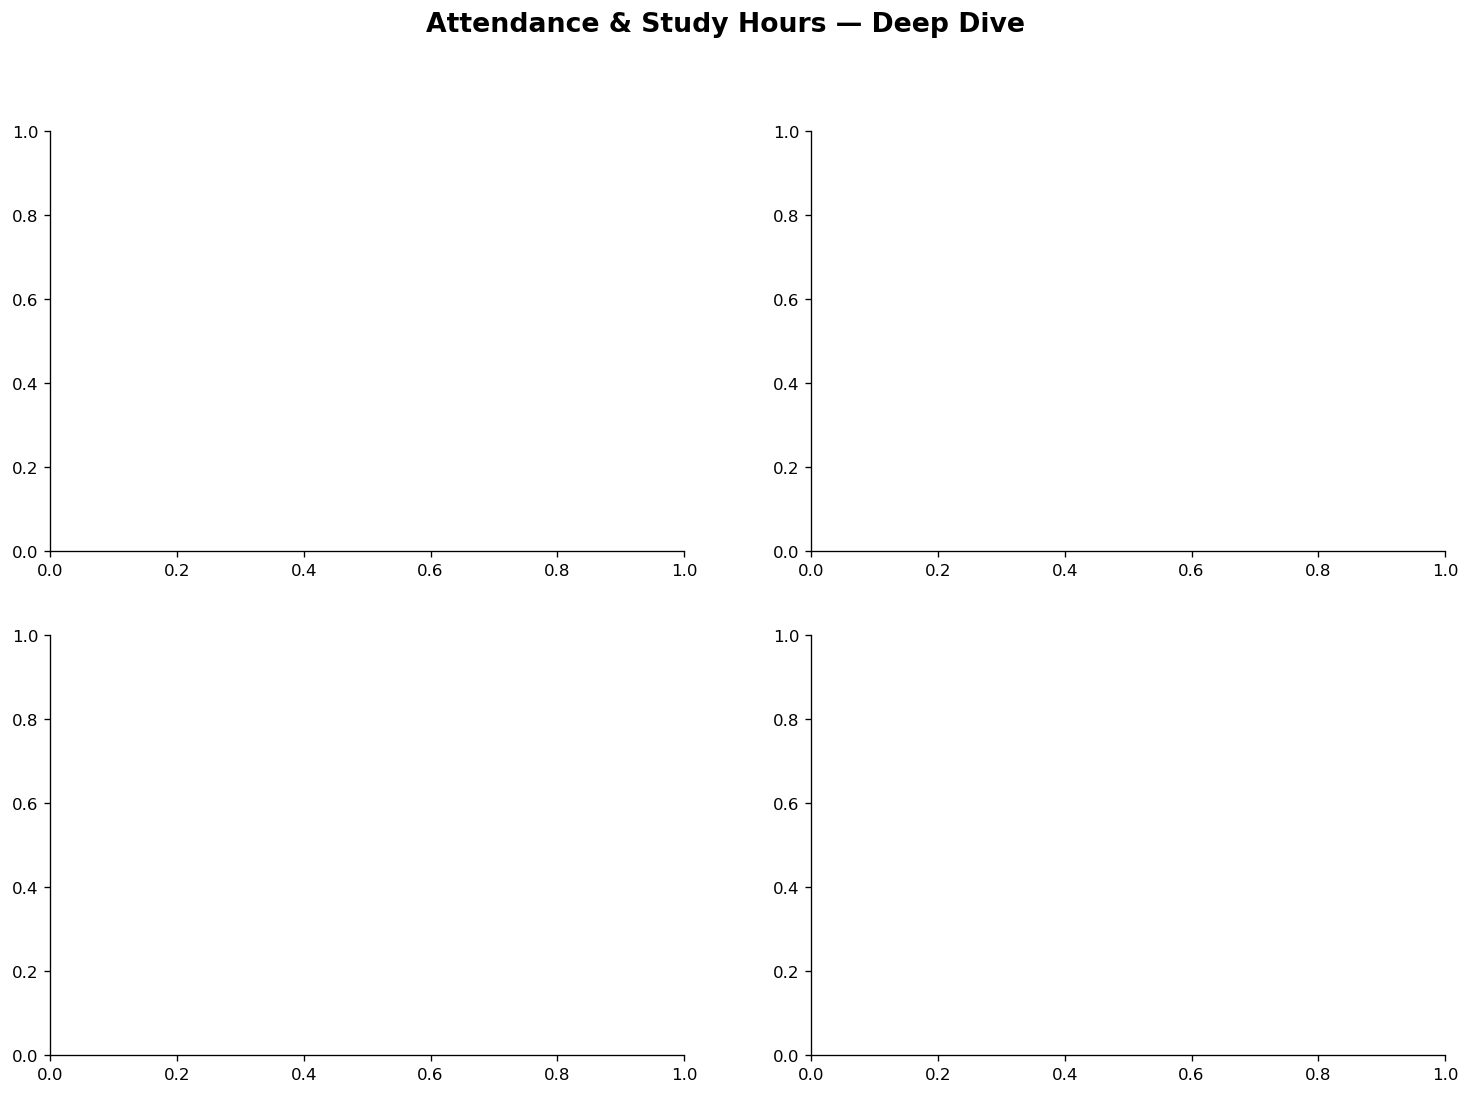

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Attendance & Study Hours — Deep Dive", fontsize=16, fontweight="bold")

In [25]:
# Attendance histogram per grade
for g, grp in df.groupby("Final_Grade"):
    axes[0,0].hist(grp["Attendance_Percent"], bins=12, alpha=0.6,
                   label=f"Grade {g}", color=grade_colors[g], edgecolor="white")
axes[0,0].set_title("Attendance Distribution by Grade")
axes[0,0].set_xlabel("Attendance %"); axes[0,0].set_ylabel("Frequency")
axes[0,0].legend()

In [26]:
# Study hours histogram per grade
for g, grp in df.groupby("Final_Grade"):
    axes[0,1].hist(grp["Study_Hours_Per_Day"], bins=10, alpha=0.6,
                   label=f"Grade {g}", color=grade_colors[g], edgecolor="white")
axes[0,1].set_title("Study Hours Distribution by Grade")
axes[0,1].set_xlabel("Study Hours / Day"); axes[0,1].set_ylabel("Frequency")
axes[0,1].legend()

In [27]:
# Bubble chart
sc = axes[1,0].scatter(df["Study_Hours_Per_Day"], df["Attendance_Percent"],
                        c=df["Average_Marks"], cmap="RdYlGn", s=80,
                        alpha=0.8, edgecolors="gray", linewidths=0.3)
plt.colorbar(sc, ax=axes[1,0], label="Avg Marks")
axes[1,0].set_title("Study Hours × Attendance\n(colour = Score)")
axes[1,0].set_xlabel("Study Hours / Day"); axes[1,0].set_ylabel("Attendance %")

Text(5.333333333333354, 0.5, 'Attendance %')

<Figure size 768x576 with 0 Axes>

In [28]:
# Grouped bar: avg study hours & attendance per grade
grade_order = ["A", "B", "C"]
avg_by_grade = df.groupby("Final_Grade")[["Study_Hours_Per_Day","Attendance_Percent"]].mean().reindex(grade_order)
x = np.arange(3); w = 0.35
axes[1,1].bar(x - w/2, avg_by_grade["Study_Hours_Per_Day"], w,
              color="#4C72B0", alpha=0.8, label="Study Hrs/Day")
ax2 = axes[1,1].twinx()
ax2.bar(x + w/2, avg_by_grade["Attendance_Percent"], w,
        color="#DD8452", alpha=0.8, label="Attendance %")
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(grade_order)
axes[1,1].set_title("Avg Study Hrs & Attendance per Grade")
axes[1,1].set_ylabel("Study Hours / Day"); ax2.set_ylabel("Attendance %")
axes[1,1].legend(loc="upper left"); ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig("plots/04_attendance_studyhours.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: plots/04_attendance_studyhours.png")

<Figure size 768x576 with 0 Axes>

✅ Saved: plots/04_attendance_studyhours.png


In [29]:
# Student Performance Comparison

In [30]:
fig = plt.figure(figsize=(18, 7))
fig.suptitle("Subject Performance per Grade", fontsize=16, fontweight="bold")

Text(0.5, 0.98, 'Subject Performance per Grade')

<Figure size 2160x840 with 0 Axes>

In [31]:
# Radar chart
ax_radar = fig.add_subplot(1, 2, 1, polar=True)
N = len(subjects)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

for grade, grp in df.groupby("Final_Grade"):
    values = grp[subjects].mean().tolist()
    values += values[:1]
    ax_radar.plot(angles, values, label=f"Grade {grade}",
                  color=grade_colors[grade], linewidth=2)
    ax_radar.fill(angles, values, alpha=0.12, color=grade_colors[grade])

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(["Math", "Physics", "Chem", "English", "CS"], fontsize=10)
ax_radar.set_ylim(0, 100)
ax_radar.set_title("Avg Subject Score — Radar", pad=20)
ax_radar.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

In [32]:
# Violin per subject per grade
ax_v = fig.add_subplot(1, 2, 2)
positions, data_pts, tick_labels, colors_list = [], [], [], []
pos = 1
for subj in subjects:
    for grade in ["A", "B", "C"]:
        grp_data = df[df["Final_Grade"] == grade][subj].dropna().values
        data_pts.append(grp_data)
        positions.append(pos)
        colors_list.append(grade_colors[grade])
        tick_labels.append(f"{subj[:4]}\n{grade}")
        pos += 1
    pos += 0.5

parts = ax_v.violinplot(data_pts, positions=positions, showmedians=True, widths=0.7)
for body, color in zip(parts["bodies"], colors_list):
    body.set_facecolor(color); body.set_alpha(0.6)
ax_v.set_xticks(positions)
ax_v.set_xticklabels(tick_labels, fontsize=7)
ax_v.set_title("Score Distribution per Subject & Grade")
ax_v.set_ylabel("Marks")

Text(0, 0.5, 'Marks')

In [33]:
from matplotlib.patches import Patch
ax_v.legend(handles=[Patch(facecolor=grade_colors[g], label=f"Grade {g}") for g in ["A","B","C"]])

plt.tight_layout()
plt.savefig("plots/05_subject_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: plots/05_subject_comparison.png")

<Figure size 768x576 with 0 Axes>

✅ Saved: plots/05_subject_comparison.png


In [34]:
# Top vs Bottom Performer Analysis

In [35]:
top10 = df.nlargest(10, "Average_Marks").reset_index(drop=True)
bot10 = df.nsmallest(10, "Average_Marks").reset_index(drop=True)

print("=== Top 10 Students ===")
print(top10[["Student_ID", "Average_Marks", "Final_Grade", "Attendance_Percent", "Study_Hours_Per_Day"]].to_string(index=False))
print("\n=== Bottom 10 Students ===")
print(bot10[["Student_ID", "Average_Marks", "Final_Grade", "Attendance_Percent", "Study_Hours_Per_Day"]].to_string(index=False))


=== Top 10 Students ===
Student_ID  Average_Marks Final_Grade  Attendance_Percent  Study_Hours_Per_Day
      S065          95.33           A               77.24                 2.52
      S056          90.33           A               77.24                 2.65
      S014          86.20           A               71.00                 1.80
      S053          85.60           A               92.00                 4.20
      S004          84.60           B               72.00                 1.70
      S059          84.60           B               78.00                 4.10
      S074          83.00           B               77.24                 2.52
      S077          82.60           B               94.00                 0.70
      S101          81.60           B               57.00                 0.50
      S073          81.00           B               83.00                 4.70

=== Bottom 10 Students ===
Student_ID  Average_Marks Final_Grade  Attendance_Percent  Study_Hours_Per_Day


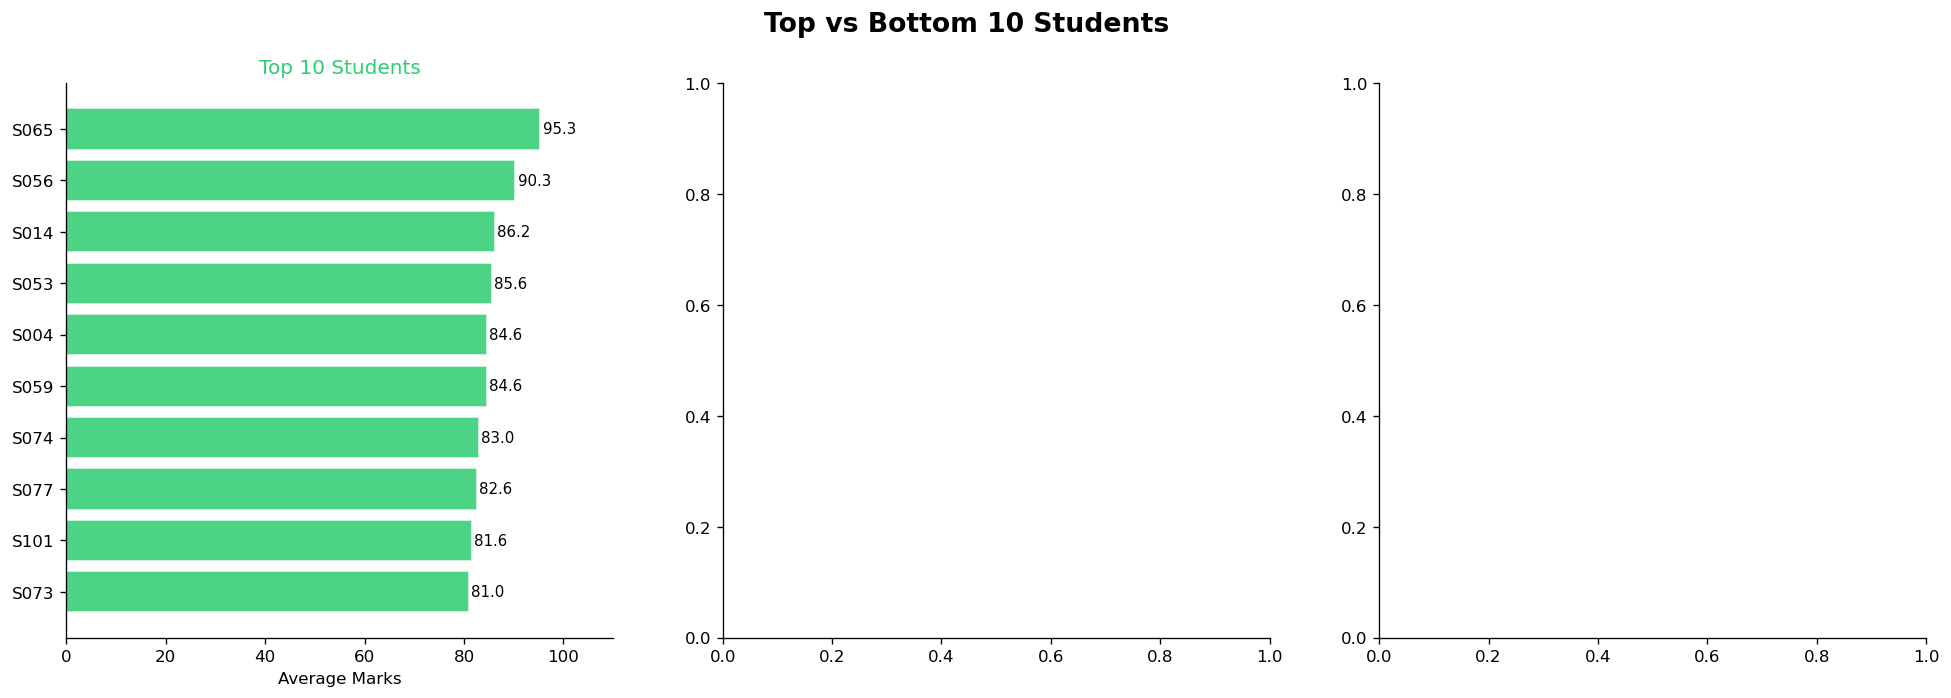

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Top vs Bottom 10 Students", fontsize=16, fontweight="bold")

# Top 10
axes[0].barh(top10["Student_ID"][::-1], top10["Average_Marks"][::-1],
             color="#2ecc71", edgecolor="white", alpha=0.85)
axes[0].set_title("Top 10 Students", color="#2ecc71")
axes[0].set_xlabel("Average Marks"); axes[0].set_xlim(0, 110)
for i, (sid, val) in enumerate(zip(top10["Student_ID"][::-1], top10["Average_Marks"][::-1])):
    axes[0].text(val + 0.5, i, f"{val:.1f}", va="center", fontsize=9)

In [37]:
# Bottom 10
axes[1].barh(bot10["Student_ID"][::-1], bot10["Average_Marks"][::-1],
             color="#e74c3c", edgecolor="white", alpha=0.85)
axes[1].set_title("Bottom 10 Students", color="#e74c3c")
axes[1].set_xlabel("Average Marks"); axes[1].set_xlim(0, 110)
for i, (sid, val) in enumerate(zip(bot10["Student_ID"][::-1], bot10["Average_Marks"][::-1])):
    axes[1].text(val + 0.5, i, f"{val:.1f}", va="center", fontsize=9)

In [38]:
# Subject comparison
x = range(len(subjects)); w = 0.35
axes[2].bar([i - w/2 for i in x], top10[subjects].mean().values, w, label="Top 10", color="#2ecc71", alpha=0.8)
axes[2].bar([i + w/2 for i in x], bot10[subjects].mean().values, w, label="Bottom 10", color="#e74c3c", alpha=0.8)
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(["Math","Physics","Chem","English","CS"], rotation=15)
axes[2].set_title("Subject Avg: Top vs Bottom Group")
axes[2].set_ylabel("Average Marks"); axes[2].legend()

In [39]:
plt.tight_layout()
plt.savefig("plots/06_top_bottom_students.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: plots/06_top_bottom_students.png")

<Figure size 768x576 with 0 Axes>

✅ Saved: plots/06_top_bottom_students.png


In [40]:
# LLM Integeration

In [41]:
import anthropic
import os

In [42]:
def build_stats_summary(df):
    """Build a compact statistics string to send to Claude."""
    grade_dist = df["Final_Grade"].value_counts().to_dict()
    subject_avgs = {s: round(df[s].mean(), 1) for s in subjects}
    weakest = df[subjects].mean().idxmin()
    strongest = df[subjects].mean().idxmax()
    return f"""
Student Dataset — {len(df)} students
Grade Distribution: {grade_dist}
Subject Average Scores: {subject_avgs}
Weakest Subject: {weakest} ({df[weakest].mean():.1f})
Strongest Subject: {strongest} ({df[strongest].mean():.1f})
Average Attendance: {df['Attendance_Percent'].mean():.1f}%
Average Study Hours/Day: {df['Study_Hours_Per_Day'].mean():.2f}
Average Score: {df['Average_Marks'].mean():.1f}
Study Hours ↔ Score correlation: {df['Study_Hours_Per_Day'].corr(df['Average_Marks']):.3f}
Attendance ↔ Score correlation: {df['Attendance_Percent'].corr(df['Average_Marks']):.3f}
""".strip()

print(build_stats_summary(df))

Student Dataset — 120 students
Grade Distribution: {'C': 60, 'B': 49, 'D': 7, 'A': 4}
Subject Average Scores: {'Math': np.float64(68.0), 'Physics': np.float64(67.8), 'Chemistry': np.float64(66.2), 'English': np.float64(68.0), 'Computer_Science': np.float64(70.5)}
Weakest Subject: Chemistry (66.2)
Strongest Subject: Computer_Science (70.5)
Average Attendance: 76.2%
Average Study Hours/Day: 2.70
Average Score: 68.3
Study Hours ↔ Score correlation: -0.007
Attendance ↔ Score correlation: 0.223


In [43]:
PROMPTS = {
    "summary": (
        "You are an expert educational data analyst.\n"
        "Give a concise 5-point summary of this class performance, highlighting key trends.\n\n{stats}\n\nFormat as a numbered list."
    ),
    "recommendations": (
        "You are an experienced teacher.\n"
        "Give 5 specific, data-driven recommendations to improve student outcomes based on:\n\n{stats}"
    ),
    "at_risk": (
        "You are an academic advisor.\n"
        "Describe the at-risk student profile and list 3-4 early warning indicators based on:\n\n{stats}\n\nBe specific and empathetic."
    ),
    "subject_focus": (
        "You are a curriculum specialist.\n"
        "Based on subject-wise scores below, identify which subjects need the most attention and suggest strategies.\n\n{stats}"
    ),
}

def get_insight(insight_type):
    """Call Claude API and return AI insight text."""
    stats = build_stats_summary(df)
    prompt = PROMPTS[insight_type].format(stats=stats)
    client = anthropic.Anthropic()
    message = client.messages.create(
        model="claude-sonnet-4-20250514",
        max_tokens=700,
        messages=[{"role": "user", "content": prompt}]
    )
    return message.content[0].text


In [48]:
import os
os.environ["ANTHROPIC_API_KEY"] = "your-api-key-here"

In [49]:
import os
import anthropic

os.environ["ANTHROPIC_API_KEY"] = "sk-ant-..."  # ← paste your key here

# Now run your insight
print("=" * 60)
print("CLASS PERFORMANCE SUMMARY")
print("=" * 60)
result = get_insight("summary")
print(result)

CLASS PERFORMANCE SUMMARY


AuthenticationError: Error code: 401 - {'type': 'error', 'error': {'type': 'authentication_error', 'message': 'invalid x-api-key'}, 'request_id': 'req_011CZJEFZC2FeT5g21XGs3xa'}

In [50]:
from dotenv import load_dotenv
load_dotenv()  # reads from a .env file

False

In [51]:
# 📋 Class Performance Summary
print("=" * 60)
print("CLASS PERFORMANCE SUMMARY")
print("=" * 60)
result = get_insight("summary")
print(result)


CLASS PERFORMANCE SUMMARY


AuthenticationError: Error code: 401 - {'type': 'error', 'error': {'type': 'authentication_error', 'message': 'invalid x-api-key'}, 'request_id': 'req_011CZJEGFRU6NQHNgsGnm8NB'}

In [45]:
# 💡 Teacher Recommendations
print("=" * 60)
print("TEACHER RECOMMENDATIONS")
print("=" * 60)
result = get_insight("recommendations")
print(result)

TEACHER RECOMMENDATIONS


TypeError: "Could not resolve authentication method. Expected either api_key or auth_token to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"

In [46]:
# ⚠️ At-Risk Student Profile
print("=" * 60)
print("AT-RISK STUDENT PROFILE")
print("=" * 60)
result = get_insight("at_risk")
print(result)


AT-RISK STUDENT PROFILE


TypeError: "Could not resolve authentication method. Expected either api_key or auth_token to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"

In [47]:
# 📚 Subject Improvement Focus
print("=" * 60)
print("SUBJECT IMPROVEMENT FOCUS")
print("=" * 60)
result = get_insight("subject_focus")
print(result)


SUBJECT IMPROVEMENT FOCUS


TypeError: "Could not resolve authentication method. Expected either api_key or auth_token to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"